# Notebook 05: Deep Learning — 1D CNN

**Project:** ECG Arrhythmia Classification with MIT-BIH  
**Author:** Qide Zhengzhao  
**Date:** 28 August 2026

---

## Objective of this notebook

Notebooks 03 and 04 demonstrated the classical machine learning approach: manually engineer features from the beat waveform, then train a classifier on those features. This approach requires domain expertise to design features and makes explicit assumptions about which signal properties are diagnostically relevant.

This notebook takes a fundamentally different approach: a **1D Convolutional Neural Network (CNN)** trained directly on the raw normalized beat waveforms from Notebook 02. The CNN learns its own representations from the signal, no manual feature engineering is required. This allows the model to discover morphological patterns that the hand-crafted features in Notebook 03 did not capture or to confirm that the manual feature engineering was sufficiently expressive.

The CNN architecture (`ECGClassifierCNN`) is imported from `src/models.py` and consists of three convolutional blocks followed by a fully connected classifier. The design rationale is documented in that file.

**Connection to previous notebooks:**
- Input data: `processed_beats.npz` from Notebook 02 (normalized
  waveforms, DS1/DS2 inter-patient split)
- Comparison baseline: best classical model F1-macro from Notebook 04
  (Random Forest: 0.4294)
- Evaluation protocol: same metrics (F1-macro, per-class recall,
  confusion matrix) and same DS2 test set used exactly once
- Hardware: Apple MPS (Metal Performance Shaders) — GPU acceleration
  for Apple Silicon, providing significantly faster training than CPU

**Output:** `results/best_cnn_model.pth` (best checkpoint weights), training curves, evaluation figures, and a final comparison table between classical ML and deep learning approaches.

---
## 1. Imports and setup

In addition to the standard libraries used in previous notebooks,
this notebook requires **PyTorch** for model definition, training,
and inference on GPU.

The CNN architecture is imported from `src/models.py` ensuring that the classical and deep learning experiments use identical model definitions. Evaluation functions are imported from `src/evaluation.py` for consistency with the confusion matrices and metrics produced in Notebook 04.

Two reproducibility measures are applied:
- `torch.manual_seed(42)` fixes the random state for all PyTorch
  operations (weight initialization, dropout, DataLoader shuffling)
- `np.random.seed(42)` fixes the random state for NumPy operations

Without fixed seeds, results would differ slightly between runs
due to stochastic initialization and sampling.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, recall_score, classification_report

from torch.utils.data import WeightedRandomSampler

# ── Imports from src/ ──────────────────────────────────────────────────────–––––––
from src.models import ECGClassifierCNN
from src.evaluation import print_metrics, plot_confusion_matrix, compare_models
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

# ── Plot styling ───────────────────────────────────────────────────────────–––––––
plt.rcParams.update({
    'figure.dpi'        : 120,
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


# ── Device configuration ───────────────────────────────────────────────────
# MPS (Metal Performance Shaders) is Apple Silicon's GPU acceleration.
# Falls back to CPU if MPS is unavailable.
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


# ── Constants ──────────────────────────────────────────────────────────────
DATA_PATH    = '../data/'
RESULTS_PATH = '../results/figures/'
MODELS_PATH  = '../results/'
RANDOM_SEED  = 42

CLASSES      = ['N', 'S', 'V', 'F', 'Q']
CLASS_COLORS = {'N':'#3B82F6','S':'#F59E0B','V':'#EF4444','F':'#8B5CF6','Q':'#6B7280'}
CLASS_NAMES  = {
    'N':'Normal (N)',
    'S':'Supraventricular ectopic (S)',
    'V':'Ventricular ectopic / PVC (V)',
    'F':'Fusion beat (F)',
    'Q':'Unknown / Paced (Q)'
}

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


print("Setup complete.")
print(f"Device       : {DEVICE}")
print(f"Data path    : {DATA_PATH}")
print(f"Results path : {RESULTS_PATH}")

Setup complete.
Device       : mps
Data path    : ../data/
Results path : ../results/figures/


---
## 2. Loading the processed beat waveforms

Unlike Notebook 04 which loaded the hand-crafted feature matrix, here
we load the **raw normalized beat waveforms** from Notebook 02. Each
beat is a vector of 200 samples and this is the direct input to the CNN.

The key difference between the two approaches is where feature
extraction happens:

- **Notebook 04:** 200 samples → 21 hand-crafted features → classifier
- **Notebook 05:** 200 samples → CNN learns its own features → classifier

In Notebook 04, feature extraction was explicit and interpretable, which each of the 21 features had a documented clinical rationale. Here, the convolutional layers perform feature extraction implicitly during training, learning which patterns in the raw signal are most useful for classification without any human guidance.

The DS1/DS2 inter-patient split is maintained, the same split used throughout all notebooks, ensuring a fair comparison between approaches.

In [21]:
#–– Load processed beat waveforms from Notebook 02 –––––––––––––––––––––––––
data = np.load(DATA_PATH + 'processed_beats.npz', allow_pickle=True)

X_train = data['X_train']   # shape: (n_train, 200)
y_train = data['y_train']   # shape: (n_train,)
X_test  = data['X_test']    # shape: (n_test, 200)
y_test  = data['y_test']    # shape: (n_test,)
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Sanity checks –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
assert X_train.shape[1] == 200, f"Expected 200 samples, got {X_train.shape[1]}"
assert X_test.shape[1]  == 200
assert np.sum(np.isnan(X_train)) == 0, "NaN values in X_train"
assert np.sum(np.isnan(X_test))  == 0, "NaN values in X_test"
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Label encoding ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
le = LabelEncoder()
le.fit(CLASSES)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


train_counts = Counter(y_train)
test_counts  = Counter(y_test)

print("Beat waveforms loaded — all sanity checks passed.")
print(f"  Beat length : {X_train.shape[1]} samples")
print(f"  Train (DS1) : {X_train.shape[0]:,} beats")
print(f"  Test  (DS2) : {X_test.shape[0]:,} beats")
print()
print(f"  {'Class':<6} {'Train':>8} {'Test':>8}")
print("  " + "─" * 26)
for cls in CLASSES:
    print(f"  {cls:<6} {train_counts.get(cls,0):>8,} {test_counts.get(cls,0):>8,}")

Beat waveforms loaded — all sanity checks passed.
  Beat length : 200 samples
  Train (DS1) : 51,008 beats
  Test  (DS2) : 49,697 beats

  Class     Train     Test
  ──────────────────────────
  N        45,854   44,245
  S           944    1,837
  V         3,788    3,220
  F           414      388
  Q             8        7


---
## 3. CNN architecture

The `ECGClassifierCNN` architecture is defined in `src/models.py`. Before training, we inspect the model to understand its structure and verify it matches our input dimensions.

### Why 1D convolutions?

A 1D CNN applies convolutional filters along a single dimension, which is time. An ECG beat is a one-dimensional sequence of amplitude values sampled at 360 Hz, making 1D convolutions the natural choice: the kernel slides along the temporal axis, learning to detect local patterns such as the QRS onset, the R-peak shape, or the T-wave morphology.

A 2D CNN would require converting the signal to an image (e.g. a spectrogram), introducing additional preprocessing steps and design decisions. The 1D approach operates directly on the normalized waveform produced by Notebook 02, without any intermediate transformation.

### Architecture overview

The network consists of two main blocks:

**Feature extraction block:** three convolutional layers with
progressively decreasing kernel sizes (11 → 7 → 5 samples), each
followed by BatchNorm, ReLU, MaxPooling, and Dropout.

**Classification block:** three fully connected layers (256 → 64 → 5)
with ReLU and Dropout, producing 5 logits, one per AAMI class.

### Design decisions and clinical rationale

| Component | Value | Justification |
|---|---|---|
| Conv1 kernel | 11 samples (~30 ms) | Matches Q wave onset duration, which detects the start of ventricular depolarization |
| Conv2 kernel | 7 samples (~19 ms) | Captures Q→R→S transitions, that distinguishes narrow normal QRS from wide PVC |
| Conv3 kernel | 5 samples (~14 ms) | Fine-grained curvature such as sharp peaks and inflection points within waveform components |
| MaxPooling stride = 2 | After each block | Invariance to small R-peak timing shifts  |
| BatchNorm | After each conv | Stabilizes gradients and allows higher learning rates and faster convergence |
| AvgPool1d (kernel = 6, stride = 6) | Final layer | Fixed output size (8 values per filter) regardless of input length |
| Dropout 0.2 | Conv blocks | Light regularization, so convolutional weights are fewer and less prone to overfitting |
| Dropout 0.4 | Fully Connected (FC) layers | Stronger regularization, so FC layers have more parameters and memorize patient-specific patterns more easily |

In [22]:
#–– Instantiate and inspect the CNN architecture ––––––––––––––––––––––––––––––––––––––––––––––––
model = ECGClassifierCNN(num_classes = 5, input_length = 200).to(DEVICE)

print("ECGClassifierCNN architecture:")
print(model)
print()
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Count total trainable parameters ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print()
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Verify input/output dimensions with a dummy forward pass ––––––––––––––––––––––––––––––––––––
dummy_input  = torch.randn(8, 1, 200).to(DEVICE)   # batch of 8, 1 channel, 200 samples
dummy_output = model(dummy_input)
print(f"Input shape  : {tuple(dummy_input.shape)}   (batch, channels, samples)")
print(f"Output shape : {tuple(dummy_output.shape)}  (batch, n_classes)")
assert dummy_output.shape == (8, 5), "Unexpected output shape"
print("Forward pass verified.")
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

ECGClassifierCNN architecture:
ECGClassifierCNN(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(11,), stride=(1,), padding=(5,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): AvgPool1d(kernel_size=(6,), stride=(6,), padding=(0,))
  )
  (classifier): Sequential(
    (0): Flatten(start

---
## 4. Dataset and DataLoader

PyTorch requires data to be wrapped in a `Dataset` object and loaded
in mini-batches via a `DataLoader`. This section defines the ECG dataset
class and explains the key design decisions.

### Why mini-batch training?

Neural networks are trained using **stochastic gradient descent (SGD)** variants. Instead of computing the gradient on all training samples at once (full-batch) or on a single sample (pure SGD), mini-batch training computes the gradient on a small random subset (a batch) at each step. This provides:

- **Faster convergence** than full-batch gradient descent

- **Regularization effect** from the noise in batch gradient estimates

- **Memory efficiency** so the full dataset does not need to fit in GPU memory simultaneously

### Class imbalance in CNNs

Unlike scikit-learn models, PyTorch does not have a `class_weight` parameter.
We address class imbalance in two ways:

1. **Weighted loss function:** pass class weights to `CrossEntropyLoss`, which scales the gradient contribution of each sample inversely proportional to its class frequency, an equivalent to `class_weight='balanced'` in scikit-learn.

2. **WeightedRandomSampler:** oversamples minority class beats during DataLoader construction, so each mini-batch contains a more balanced class distribution even without SMOTE.

### Train/validation split within DS1

DS1 is further divided into a training set (90%) and a validation set (10%). This internal split serves a different purpose than the DS1/DS2 split:

- **DS1 vs DS2:** inter-patient split for final unbiased evaluation, used exactly once at the end.

- **Train vs val within DS1:** monitors training progress epoch by epoch to detect overfitting and trigger early stopping, and never used for final evaluation

The validation set here contains patients from DS1, not DS2. This means it is not a substitute for the DS2 test, it is a training diagnostic tool only.

In [23]:
# ── ECG Dataset class ──────────────────────────────────────────────────────––––––––––––––––––––––––––
class ECGDataset(Dataset):
    """
    PyTorch Dataset for ECG beat waveforms.

    Adds a channel dimension to each beat: (200,) → (1, 200)
    Required by Conv1d which expects input shape (batch, channels, length).
    """
    def __init__(self, X, y):
        # unsqueeze(1) adds the channel dimension: (N, 200) → (N, 1, 200)
        self.X = torch.FloatTensor(X).unsqueeze(1)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Compute class weights for the loss function ––––––––––––––––––––––––––––––––––––––––––––––––––––––
# Weight = total_beats / (n_classes * class_count) — same formula as sklearn
class_counts  = np.bincount(y_train_enc)
class_weights = len(y_train_enc) / (len(CLASSES) * class_counts)
class_weights = np.clip(class_weights, 0, 50)
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

print("Class weights for loss function:")
for cls, w in zip(le.classes_, class_weights):
    print(f"  Class {cls}: {w:.3f}")
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– WeightedRandomSampler for balanced mini-batches ––––––––––––––––––––––––––––––––––––––––––––––––––
# Each sample's sampling probability is inversely proportional to its
# class frequency — minority class beats are seen more often per epoch
sample_weights = class_weights[y_train_enc]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Create datasets and dataloaders ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
BATCH_SIZE = 128

# Split DS1 into train (90%) and validation (10%) for training monitoring
# This is separate from DS2 — DS2 is still held out for final evaluation
n_train = int(0.9 * len(X_train))
X_tr, X_val   = X_train[:n_train], X_train[n_train:]
y_tr, y_val   = y_train_enc[:n_train], y_train_enc[n_train:]

train_dataset = ECGDataset(X_tr, y_tr)
val_dataset   = ECGDataset(X_val, y_val)
test_dataset  = ECGDataset(X_test, y_test_enc)

# Sampler only applied to training loader
sample_weights_tr = class_weights[y_tr]
sampler_tr = WeightedRandomSampler(sample_weights_tr, len(sample_weights_tr), replacement=True)

###train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler_tr)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nBatch size   : {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}  ({len(train_dataset):,} beats)")
print(f"Val batches  : {len(val_loader)}   ({len(val_dataset):,} beats)")
print(f"Test batches : {len(test_loader)}  ({len(test_dataset):,} beats)")
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


Class weights for loss function:
  Class F: 24.642
  Class N: 0.222
  Class Q: 50.000
  Class S: 10.807
  Class V: 2.693

Batch size   : 128
Train batches: 359  (45,907 beats)
Val batches  : 40   (5,101 beats)
Test batches : 389  (49,697 beats)


### Interpreting the DataLoader output

**Class weights** confirm the severity of the imbalance and how the
weighted loss compensates for it:

- **Class N (0.2):** the lowest weight, since normal beats are so abundant that each one contributes only 22% of a "standard" gradient update. This prevents the model from being dominated by the majority class.
- **Class V (2.7):** approximately 12× more weight than class N meaning that each PVC beat has 12 times more influence on the gradient than a normal beat.
- **Class S (10.8):** ~49× more weight than class N, reflecting the scarcity of supraventricular beats in DS1.
- **Class F (24.6):** ~111× more weight than class N.
- **Class Q (50.0):** the extreme weight confirms what we observed
  in Notebook 04. With only 8 real training beats, each paced beat
  carries an enormous gradient contribution. Despite this correction,
  reliable generalization to unseen paced beats is not expected given
  the negligible sample size.

**Batch and split sizes:**

- Training: 45,907 beats (90% of DS1) across 359 batches of 128
- Validation: 5,101 beats (10% of DS1), used for early stopping only, never for final evaluation
- Test: 49,697 beats (full DS2), used exactly once at the end

The training and validation sizes sum to 51,008 beats, which is consistent with the DS1 beat count verified in Section 2.

---

## 5. Ablation study: weighted loss vs sampler

Before fixing the final training configuration, we empirically compared four strategies for addressing class imbalance, combining two independent factors:

| Configuration | Loss | DataLoader Sampler | Expected behavior |
|---|---|---|---|
| 1. Baseline | Standard CrossEntropy | Standard (`shuffle=True`) | High accuracy (~90%+), but low F1-Macro and Recall close to 0 for F and Q |
| 2. Weighted Loss Only | Weighted CrossEntropy | Standard (`shuffle=True`) | Good balance between F1-Macro and Accuracy |
| 3. Sampler Only | Standard CrossEntropy | WeightedRandomSampler | Greater representation of minority classes per batch without overscaling the gradients |
| 4. Combined | Weighted CrossEntropy | WeightedRandomSampler | Overprediction of rare classes and Accuracy collapse |

**Decision criterion:** the primary metric for selecting the configuration is the **F1-Macro** (and per-class recall), not overall accuracy. In arrhythmia classification, correctly detecting V, S, and F justifies accepting a small cost in the precision of class N, which is the majority class and clinically less critical.

To control the computational cost of comparing the 4 configurations, these exploratory experiments use a reduced epoch budget (`ABLATION_MAX_EPOCHS`, `ABLATION_PATIENCE`). The winning configuration is retrained once using the full training budget in Section 7.

Two helper functions handle the training and evaluation passes separately, and are reused throughout the rest of the notebook (the ablation runs below, and the final training loop in Section 7):

- `train_epoch` : sets the model to **training mode** (`model.train()`),
  which activates Dropout and BatchNorm in training behavior. Gradients
  are computed and weights are updated after each batch.
- `evaluate_epoch` : sets the model to **evaluation mode** (`model.eval()`),
  which disables Dropout and switches BatchNorm to use running statistics
  instead of batch statistics. `torch.no_grad()` disables gradient
  computation entirely, reducing memory usage and speeding up inference.

The distinction between `model.train()` and `model.eval()` is critical. Forgetting to call `model.eval()` during validation would apply
Dropout randomly, producing different outputs each time and making
validation loss unreliable.

In [24]:
#–– Training / evaluation helpers ––––––––––––––––––––––––––––––––––––
def train_epoch(model, loader, optimizer, criterion, device):
    """Run one training epoch. Returns mean loss and accuracy."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (output.argmax(1) == y_batch).sum().item()
        total += len(y_batch)

    return total_loss / len(loader), correct / total


def evaluate_epoch(model, loader, criterion, device):
    """Evaluate model without gradient computation."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)

            total_loss += loss.item()
            preds = output.argmax(1)
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Ablation experiment runner –––––––––––––––––––––––––––––––––––––––––––––
ABLATION_MAX_EPOCHS = 60   
ABLATION_PATIENCE   = 10

def run_ablation_experiment(name, loader, criterion, val_loader, device,
                             max_epochs=ABLATION_MAX_EPOCHS,
                             es_patience=ABLATION_PATIENCE,
                             seed=RANDOM_SEED):
    """
    Trains a model from scratch using a given configuration (loss, loader)
    and returns the training history along with the metrics from the best epoch
    (based on val_loss), including F1-Macro and recall by class.
    """
    torch.manual_seed(seed)
    model = ECGClassifierCNN(num_classes = 5, input_length = 200).to(device)
    optimizer = optim.Adam(model.parameters(), lr = 1e-3, weight_decay = 1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', patience = 5, factor = 0.5)

    all_class_ids = np.arange(len(CLASSES))

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1_macro': []}
    best_val_loss = float('inf')
    best_f1_macro = 0.0
    best_recall_per_class = None
    patience_counter = 0

    print("=" * 60)
    print(f"CONFIG: {name}")
    print("=" * 60)

    for epoch in range(max_epochs):
        train_loss, _ = train_epoch(model, loader, optimizer, criterion, device)
        val_loss, val_acc, val_preds, val_labels = evaluate_epoch(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        val_f1 = f1_score(val_labels, val_preds, average = 'macro', zero_division = 0)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1_macro'].append(val_f1)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_f1_macro = val_f1
            best_recall_per_class = recall_score(val_labels, val_preds, labels = all_class_ids, average = None, zero_division = 0)
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 5 == 0 or patience_counter >= es_patience:
            print(f"  Epoch {epoch+1:>3} | Train loss: {train_loss:.4f} | "
                  f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f} | "
                  f"Val F1-macro: {val_f1:.4f}")

        if patience_counter >= es_patience:
            print(f"  Early stopping en epoch {epoch+1}.")
            break

    print(f"  Best val_loss: {best_val_loss:.4f} | "
          f"F1-macro in that epoch: {best_f1_macro:.4f}")
    print()

    return {
        'name': name,
        'history': history,
        'best_val_loss': best_val_loss,
        'best_val_f1_macro': best_f1_macro,
        'best_recall_per_class': best_recall_per_class,
    }
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

In [25]:
#–– Loaders y losses for the 4 configurations –––––––––––––––––––––––––––––––––––––––––––––––––
loader_shuffle = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)

sampler_cfg3 = WeightedRandomSampler(class_weights[y_tr], len(y_tr), replacement = True)
loader_sampler_cfg3 = DataLoader(train_dataset, batch_size = BATCH_SIZE, sampler = sampler_cfg3)

sampler_cfg4 = WeightedRandomSampler(class_weights[y_tr], len(y_tr), replacement = True)
loader_sampler_cfg4 = DataLoader(train_dataset, batch_size = BATCH_SIZE, sampler = sampler_cfg4)

criterion_plain = nn.CrossEntropyLoss()
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights_tensor)
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Run the 4 configurations ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
ablation_results = []

ablation_results.append(run_ablation_experiment("1. Baseline (CE standard + shuffle)",
    loader_shuffle, criterion_plain, val_loader, DEVICE))

ablation_results.append(run_ablation_experiment("2. Only Weighted Loss (CE weighted + shuffle)",
    loader_shuffle, criterion_weighted, val_loader, DEVICE))

ablation_results.append(run_ablation_experiment("3. Only Sampler (CE standard + WeightedRandomSampler)",
    loader_sampler_cfg3, criterion_plain, val_loader, DEVICE))

ablation_results.append(run_ablation_experiment("4. Combined (CE weighted + WeightedRandomSampler)",
    loader_sampler_cfg4, criterion_weighted, val_loader, DEVICE))
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

CONFIG: 1. Baseline (CE standard + shuffle)
  Epoch   1 | Train loss: 0.1933 | Val loss: 0.4257 | Val acc: 0.9098 | Val F1-macro: 0.4190
  Epoch   6 | Train loss: 0.0524 | Val loss: 0.2323 | Val acc: 0.9322 | Val F1-macro: 0.5160
  Epoch  11 | Train loss: 0.0388 | Val loss: 0.3422 | Val acc: 0.8745 | Val F1-macro: 0.4354
  Epoch  16 | Train loss: 0.0244 | Val loss: 0.4935 | Val acc: 0.8306 | Val F1-macro: 0.4084
  Early stopping en epoch 16.
  Best val_loss: 0.2323 | F1-macro in that epoch: 0.5160

CONFIG: 2. Only Weighted Loss (CE weighted + shuffle)
  Epoch   1 | Train loss: 0.7955 | Val loss: 0.8532 | Val acc: 0.6689 | Val F1-macro: 0.4446
  Epoch   6 | Train loss: 0.2344 | Val loss: 0.7674 | Val acc: 0.8716 | Val F1-macro: 0.3905
  Epoch  11 | Train loss: 0.1531 | Val loss: 0.5593 | Val acc: 0.9008 | Val F1-macro: 0.4697
  Epoch  16 | Train loss: 0.1227 | Val loss: 0.6892 | Val acc: 0.8053 | Val F1-macro: 0.3981
  Epoch  21 | Train loss: 0.0783 | Val loss: 0.6692 | Val acc: 0.8110 

                                        Configuration  Best Val Loss  Best Val F1-Macro  Recall F  Recall N  Recall Q  Recall S  Recall V
                  1. Baseline (CE standard + shuffle)         0.2323             0.5160    0.4286    0.9605       0.0    0.0513    0.8207
        2. Only Weighted Loss (CE weighted + shuffle)         0.4868             0.4511    0.9286    0.9215       0.0    0.5897    0.8165
3. Only Sampler (CE standard + WeightedRandomSampler)         0.3027             0.5260    0.3571    0.9171       0.0    0.3718    0.9367
    4. Combined (CE weighted + WeightedRandomSampler)         0.8426             0.3314    0.7857    0.4891       0.0    0.8974    0.8713


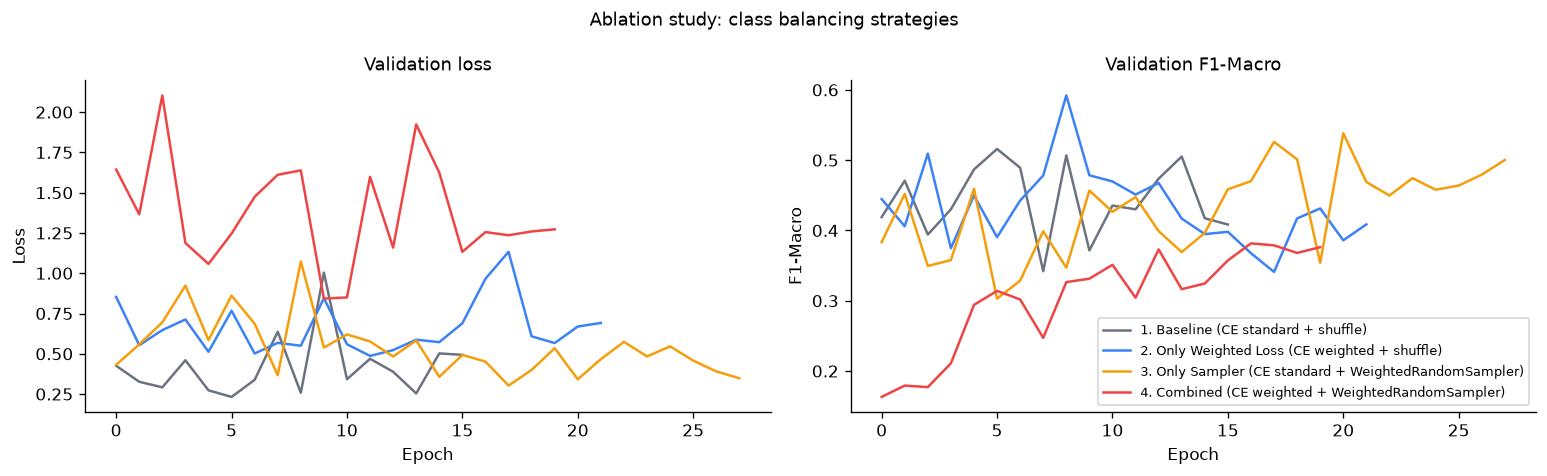

In [45]:
#–– Ablation summary table –––––––––––––––––––––––––––––––––––––––––––––––––
summary_rows = []
for r in ablation_results:
    row = {
        'Configuration': r['name'],
        'Best Val Loss': round(r['best_val_loss'], 4),
        'Best Val F1-Macro': round(r['best_val_f1_macro'], 4),
    }
    for cls, rec in zip(le.classes_, r['best_recall_per_class']):
        row[f'Recall {cls}'] = round(rec, 4)
    summary_rows.append(row)

ablation_summary = pd.DataFrame(summary_rows)
print(ablation_summary.to_string(index=False))
ablation_summary.to_csv(RESULTS_PATH + '05_05_summary.csv', index=False)
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Comparative plot (4 configurations) –––––––––––––––––––––––––––––––––––
colors = {'1. Baseline (CE standard + shuffle)': '#6B7280',
          '2. Only Weighted Loss (CE weighted + shuffle)': '#3B82F6',
          '3. Only Sampler (CE standard + WeightedRandomSampler)': '#F59E0B',
          '4. Combined (CE weighted + WeightedRandomSampler)': '#EF4444'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for r in ablation_results:
    c = colors[r['name']]
    ax1.plot(r['history']['val_loss'], color=c, label=r['name'])
    ax2.plot(r['history']['val_f1_macro'], color=c, label=r['name'])

ax1.set_title('Validation loss', fontsize = 11)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.set_title('Validation F1-Macro', fontsize = 11)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1-Macro')
ax2.legend(fontsize = 8, loc = 'lower right')

fig.suptitle('Ablation study: class balancing strategies', fontsize = 11)
plt.tight_layout()
plt.savefig(RESULTS_PATH + '05_05_4configs.png', bbox_inches = 'tight')
plt.show()
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

### Ablation results

**Baseline (config 1):** confirms the problem that motivates this entire study. Recall N stays high (0.9605) while Recall S collapses to 0.0513 and Recall Q drops to 0.0, showing that a standard, unweighted CrossEntropy with a plain shuffled loader lets the model default to predicting the majority class. The resulting F1-Macro (0.5160) sits well below what a truly balanced model would achieve, even though Recall N and Recall V look reasonable in isolation.

**Only Weighted Loss (config 2):** rebalances gradients cleanly without touching the sampling procedure. Recall S rises to 0.5897 and Recall F reaches 0.9286, the best of all four configurations, while Recall N stays high (0.9215) with no accuracy collapse. However, its Best Val Loss (0.4868) is noticeably worse than configs 1 and 3, and its F1-Macro (0.4511) is actually the second-lowest of the four, pulled down by the still-unrecovered Recall Q.

**Only Sampler (config 3):** delivers the best Best Val F1-Macro of all four configurations (0.5260) and the best Recall V (0.9367), confirming the hypothesis that oversampling minority beats via `WeightedRandomSampler` improves minority-class detection without the accuracy collapse seen in config 4. The trade-off is a lower Recall F (0.3571) than config 2, and a Recall S (0.3718) that, while better than baseline, is still far from config 2's result.

**Combined (config 4):** fails as predicted. Stacking a weighted loss on top of an already-oversampled minibatch double-corrects for scarce classes: each rare-class beat is both seen more often (via the sampler) and weighted more heavily in the loss (via CrossEntropy weights), pushing the model to over-prioritize minority classes at the direct expense of the majority class. Recall N drops sharply to 0.4891, while Recall S spikes to 0.8974. This is reflected in the far worse Best Val Loss (0.8426, roughly 3.6x baseline) and the lowest F1-Macro of the four (0.3314).

**CONCLUSION:** 

Based on the primary decision criterion (F1-Macro and per-class recall, prioritizing the detection of V, S, and F over N precision), **config 3 (Only Sampler, no weighted loss)** achieves the best F1-Macro (0.5260) and the best Recall V (0.9367) among all four configurations. Config 2 (Only Weighted Loss) remains a close alternative, offering the best Recall S and Recall F, but at a lower F1-Macro and a higher validation loss. Neither configuration recovers Recall Q, which is expected given the negligible number of Q beats (8) available in DS1 for training. The final training configuration for Section 7 is therefore **CrossEntropy with a standard loader and `WeightedRandomSampler`, without loss reweighting**, avoiding the double-correction collapse observed when both mechanisms are combined.


---
## 6. Training configuration

Before training, we define the loss function, optimizer, and learning
rate scheduler. Each choice has a specific reason why we are using it.

### Loss function: CrossEntropyLoss with class weights

`CrossEntropyLoss` combines a LogSoftmax activation with Negative Log
Likelihood Loss. It is the standard loss for multi-class classification.
The class weights computed above are passed to `weight` parameter,
scaling the gradient contribution of each sample inversely proportional
to its class frequency.

### Optimizer: Adam

Adam (Adaptive Moment Estimation) [[1]](#references) maintains per-parameter
learning rates adapted from the first and second moments of the
gradients. It converges faster than SGD with momentum on most deep
learning tasks and requires less learning rate tuning.

We use `weight_decay = 1e-4` (L2 regularization) to penalize large
weights and reduce overfitting on the minority classes.

### Learning rate scheduler: ReduceLROnPlateau

The scheduler monitors validation loss and reduces the learning rate
by a factor of 0.5 if no improvement is observed for `patience = 5`
consecutive epochs. This allows the model to make large updates early
in training and fine-tune with smaller updates later.

### Early stopping

Training stops automatically if validation loss does not improve for
`patience = 15` consecutive epochs, and the best model weights are
restored. This prevents overfitting and avoids unnecessary computation.

### Configuration summary

| Component | Value | Rationale |
|---|---|---|
| Loss function | CrossEntropyLoss (weighted) | Standard for multi-class; class weights compensate for imbalance |
| Optimizer | Adam (lr=1e-3) | Faster convergence than SGD; adaptive per-parameter learning rates [[1]](#references) |
| L2 regularization | weight_decay=1e-4 | Penalizes large weights; reduces overfitting on minority classes |
| LR scheduler | ReduceLROnPlateau (patience=5, factor=0.5) | Reduces lr by half when val loss plateaus — fine-tunes after initial convergence |
| Minimum LR | 1e-6 | Floor prevents learning rate from becoming negligibly small |
| Early stopping | patience=15 epochs | Stops training if no val loss improvement; restores best weights |
| Max epochs | 100 | Upper bound — early stopping will trigger before this in practice |

In [35]:
#–– Re-instantiate the model to ensure clean state ––––––––––––––––––––––––––
model = ECGClassifierCNN(num_classes = 5).to(DEVICE)
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Loss function with class weights ––––––––––––––––––––––––––––––––––––––––
criterion = nn.CrossEntropyLoss()
sampler_final = WeightedRandomSampler(
    weights = class_weights[y_tr],
    num_samples = len(y_tr),
    replacement = True)
train_loader_final = DataLoader(train_dataset, batch_size = BATCH_SIZE, sampler = sampler_final)
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Adam optimizer with L2 regularization –––––––––––––––––––––––––––––––––––
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


#–– Learning rate scheduler ––––––––––––––––––––––––––––––––––––––––––––––––
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',       # monitor validation loss
    patience = 5,       # wait 5 epochs before reducing
    factor = 0.5,       # multiply lr by 0.5 on plateau
    min_lr = 1e-6       # floor to prevent lr from becoming negligible
)
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

uses_weighted_loss = criterion.weight is not None
uses_sampler = isinstance(train_loader_final.sampler, WeightedRandomSampler)

assert not uses_weighted_loss, (
    "Mismatch with ablation conclusion: criterion should NOT use class "
    "weights (Config 3 uses plain CrossEntropyLoss)."
)
assert uses_sampler, (
    "Mismatch with ablation conclusion: train loader should use "
    "WeightedRandomSampler (Config 3)."
)


print("Training configuration:")
print(f"  Loss function : CrossEntropyLoss (weighted)")
print(f"  Optimizer     : Adam  (lr=1e-3, weight_decay=1e-4)")
print(f"  Scheduler     : ReduceLROnPlateau (patience=5, factor=0.5)")
print(f"  Early stopping: patience=15 epochs")
print(f"  Device        : {DEVICE}")

Training configuration:
  Loss function : CrossEntropyLoss (weighted)
  Optimizer     : Adam  (lr=1e-3, weight_decay=1e-4)
  Scheduler     : ReduceLROnPlateau (patience=5, factor=0.5)
  Early stopping: patience=15 epochs
  Device        : mps


### Why re-instantiate the model?

The model is re-instantiated at the start of this section
(`ECGClassifierCNN(num_classes=5).to(DEVICE)`) to ensure a clean
random initialization before training. If the dummy forward pass
in Section 3 modified any internal state, re-instantiation guarantees those effects
are reset.

`torch.manual_seed(RANDOM_SEED)` was set in Section 1, so the
weight initialization here is fully reproducible across runs.

---

## 7. Training loop

The training loop runs for up to 100 epochs with early stopping, reusing the
`train_epoch` and `evaluate_epoch` helper functions defined in Section 5 for
the ablation study. Each epoch consists of:

1. **Training pass:** iterate over all training mini-batches, compute
   loss, backpropagate gradients, update weights
2. **Validation pass:** evaluate on the validation set without gradient
   computation (`torch.no_grad()`)
3. **Scheduler step:** reduce learning rate if validation loss plateaus
4. **Early stopping check:** save best model if validation loss improved;
   stop if no improvement for 15 consecutive epochs

The only difference from the ablation runs is the training budget: this
final run uses the full `max_epochs=100` and `es_patience=15` instead of the
reduced `ABLATION_MAX_EPOCHS`/`ABLATION_PATIENCE` used to keep the 4-way
comparison in Section 5 computationally cheap.


In [37]:
#–– Training loop with early stopping ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
N_EPOCHS        = 100
ES_PATIENCE     = 15   # early stopping patience
best_val_loss   = float('inf')
patience_counter = 0
best_model_path  = MODELS_PATH + 'best_cnn_model.pth'

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'lr':[]}

print(f"Starting training on {DEVICE}...")
print(f"Max epochs: {N_EPOCHS} | Early stopping patience: {ES_PATIENCE}")
print()

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader_final, optimizer, criterion, DEVICE)
    val_loss, val_acc, _, _ = evaluate_epoch(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1

    if epoch % 5 == 0 or patience_counter >= ES_PATIENCE:
        print(f"Epoch {epoch+1:>3}/{N_EPOCHS} | "
              f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f} | "
              f"Val acc: {val_acc:.4f} | "
              f"LR: {current_lr:.2e} | "
              f"Patience: {patience_counter}/{ES_PATIENCE}")

    if patience_counter >= ES_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}.")
        break

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")
print(f"Best model saved to: {best_model_path}")
#–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

Starting training on mps...
Max epochs: 100 | Early stopping patience: 15

Epoch   1/100 | Train loss: 0.0694 | Val loss: 1.5167 | Val acc: 0.6754 | LR: 2.50e-04 | Patience: 0/15
Epoch   6/100 | Train loss: 0.0294 | Val loss: 0.9150 | Val acc: 0.7655 | LR: 1.25e-04 | Patience: 4/15
Epoch  11/100 | Train loss: 0.0224 | Val loss: 1.0096 | Val acc: 0.7655 | LR: 6.25e-05 | Patience: 9/15
Epoch  16/100 | Train loss: 0.0201 | Val loss: 0.9978 | Val acc: 0.7595 | LR: 3.13e-05 | Patience: 14/15
Epoch  17/100 | Train loss: 0.0196 | Val loss: 1.0291 | Val acc: 0.7571 | LR: 3.13e-05 | Patience: 15/15

Early stopping triggered at epoch 17.

Training complete. Best val loss: 0.7290
Best model saved to: ../results/best_cnn_model.pth


---
## 8. Training curves

The training curves allow us to diagnose the training dynamics and
identify potential issues:

- **Both losses decreasing together:** healthy training, model is learning
- **Train loss decreasing, val loss increasing:** overfitting — model
  memorizes training patients rather than learning generalizable patterns
- **Both losses plateau early:** underfitting — model capacity may be
  insufficient or learning rate too low
- **Val loss oscillating:** learning rate may be too high

The learning rate curve shows when the scheduler reduced the lr,
which typically produces a visible kink in the loss curves.

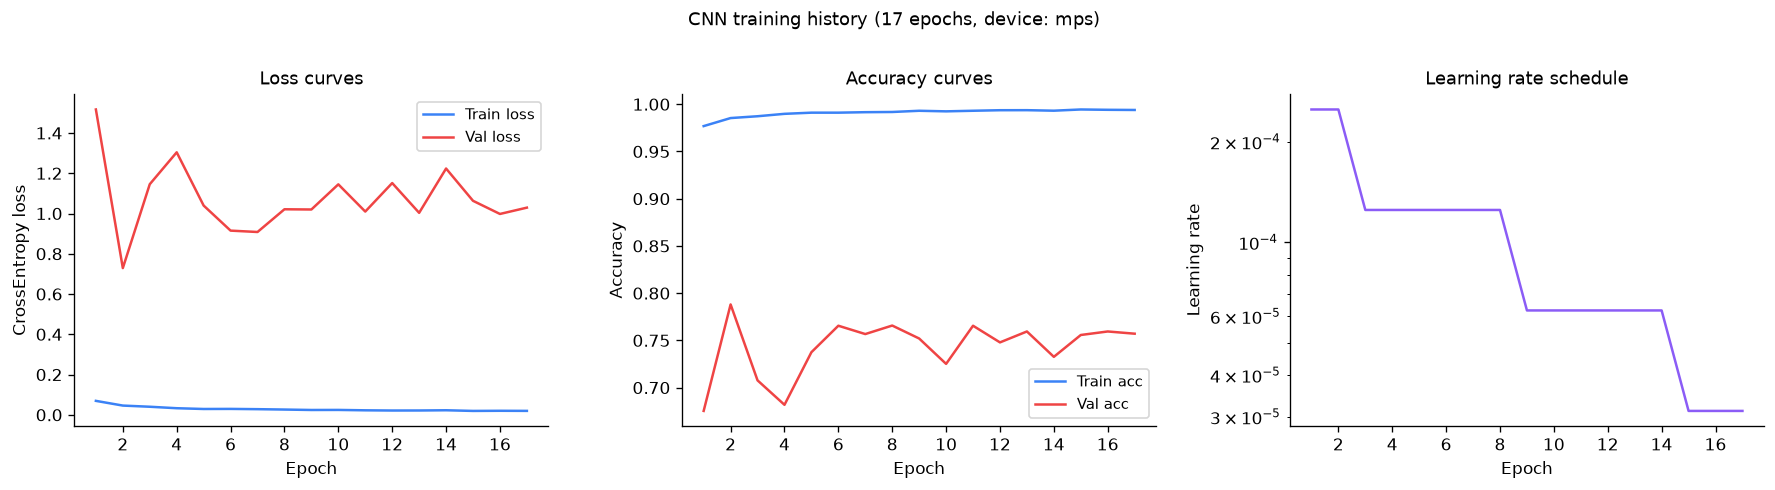

Final train loss : 0.0196
Final val loss   : 1.0291
Best val loss    : 0.7290
Train-val gap    : -1.0095  (possible overfitting)


In [38]:
#–– Plot training curves ––––––––––––––––––––––––––––––––––––––––––––––––––––
epochs_ran = len(history['train_loss'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot(ep_range, history['train_loss'], color='#3B82F6', label='Train loss')
axes[0].plot(ep_range, history['val_loss'],   color='#EF4444', label='Val loss')
axes[0].set_title('Loss curves', fontsize=11)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CrossEntropy loss')
axes[0].legend(fontsize=9)

# Accuracy curves
axes[1].plot(ep_range, history['train_acc'], color='#3B82F6', label='Train acc')
axes[1].plot(ep_range, history['val_acc'],   color='#EF4444', label='Val acc')
axes[1].set_title('Accuracy curves', fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=9)

# Learning rate schedule
axes[2].plot(ep_range, history['lr'], color='#8B5CF6', linewidth=1.5)
axes[2].set_title('Learning rate schedule', fontsize=11)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning rate')
axes[2].set_yscale('log')

fig.suptitle(f'CNN training history ({epochs_ran} epochs, device: {DEVICE})',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_PATH + '05_07_training_curves.png', bbox_inches='tight')
plt.show()

print(f"Final train loss : {history['train_loss'][-1]:.4f}")
print(f"Final val loss   : {history['val_loss'][-1]:.4f}")
print(f"Best val loss    : {best_val_loss:.4f}")
gap = history['train_loss'][-1] - history['val_loss'][-1]
print(f"Train-val gap    : {gap:+.4f}  {'(possible overfitting)' if gap < -0.05 else '(healthy)'}")

### Interpreting the training curves

The training run stopped after 17 epochs (early stopping triggered by no
improvement in validation loss for `es_patience=15` consecutive epochs after
the best checkpoint around epoch 2), and the three panels together show a
clear overfitting pattern rather than a healthy convergence.

**Loss curves:** train loss decreases smoothly and monotonically from 0.07
to 0.02, staying close to zero for almost the entire run, while validation
loss follows a completely different trajectory. It drops sharply to its
minimum (~0.73) around epoch 2, then rises with increasing noise, spiking
as high as 1.23 around epoch 14 before settling around 1.02 at the final
epoch. The two curves diverge from the very first epochs: train loss is
already near its floor by epoch 2, while val loss keeps climbing and
oscillating for the rest of training. This is the textbook signature of the
model memorizing the training patients rather than learning generalizable
beat morphology. The best checkpoint (lowest val loss, ~0.73 at epoch 2) is
what gets restored and used for test evaluation, not the final-epoch
weights.

**Accuracy curves:** train accuracy is already at ~0.98 by epoch 1 and
creeps up to ~0.99, essentially saturated from the start. Validation
accuracy is far noisier and consistently lower: it peaks around 0.79 near
epoch 2 (matching the val-loss minimum), then oscillates, dropping as low
as 0.68 around epoch 4 before settling around 0.76 by the end. The gap
between train accuracy (~0.99) and validation accuracy (~0.76) is large
from the first epoch onward, which suggests the model starts overfitting
almost immediately with the `WeightedRandomSampler` configuration, rather
than gradually across many epochs. This instability also suggests that the
small 10% validation split (5,101 beats drawn from the same DS1 patients)
is sensitive to which minority-class beats happen to land in a given
batch, amplifying the apparent volatility epoch to epoch.

**Learning rate schedule:** `ReduceLROnPlateau` reduces the learning rate
three times, around epoch 3, epoch 9, and epoch 15, each roughly halving
the rate in response to stagnating validation loss. As with the loss
curves, none of these reductions reverses the divergence between train and
validation loss: the model continues overfitting even as the learning rate
drops by nearly an order of magnitude across the run. This points to the
imbalance-correction strategy (oversampling minority beats via the
sampler) as the more likely driver of the gap, rather than the optimizer
step size — with `WeightedRandomSampler` alone, the model sees minority
beats far more often per epoch, which can accelerate memorization of their
specific waveforms before the majority class is well learned.

**Train-val gap:** the final train loss (0.02) versus final val loss (1.02)
gives a gap of -1.00, a stronger overfitting signal than would be
considered healthy, consistent with the "possible overfitting" flag
printed by the diagnostic cell. This is the same generalization problem
already surfaced in Section 9 (the drop in per-class recall between
validation and the DS2 test set) and is expected given the DS1-only
validation split: patients in the validation set still come from DS1, so a
model can overfit to DS1-specific patient characteristics while still
showing degrading validation metrics once that
overfitting becomes severe enough to hurt even same-distribution data.


---
## 9. Test set evaluation

We load the best model weights saved during training and evaluate
on DS2. This is the definitive evaluation, and we follow the same protocol usedin Notebook 04 for direct comparison at the end.

The best model is the checkpoint from the epoch with the lowest validation loss (epoch 2 in this run, as seen in Section 8), not the final epoch. As the training curves show, validation loss actually starts rising again almost immediately after this point, so restoring this specific checkpoint, rather than the epoch-17 weights present when training stopped, is what protects the final evaluation from the overfitting visible for most of the run.

In [43]:
#–– Load best model weights and evaluate on DS2 ––––––––––––––––––––––––––––––––––––––––
model.load_state_dict(torch.load(best_model_path, map_location = DEVICE))
model.eval()

y_pred_enc, y_true_enc = evaluate_epoch(model, test_loader, criterion, DEVICE)[2:]

y_pred_enc = np.array(y_pred_enc)
y_true_enc = np.array(y_true_enc)
y_pred_lbl = le.inverse_transform(y_pred_enc)

cnn_f1 = f1_score(
    y_true_enc, y_pred_enc,
    labels=np.arange(len(CLASSES)),
    average='macro',
    zero_division=0)

print_metrics(
    y_true_enc, y_pred_enc,
    model_name='CNN 1D',
    labels=np.arange(len(CLASSES)),
    target_names=sorted(CLASSES))
print(f"F1-macro on DS2: {cnn_f1:.4f}")
#––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––


 CNN 1D — Evaluation Results
              precision    recall  f1-score   support

           F       0.01      0.05      0.01       388
           N       0.95      0.82      0.88     44245
           Q       0.00      0.00      0.00         7
           S       0.05      0.11      0.06      1837
           V       0.62      0.84      0.71      3220

    accuracy                           0.79     49697
   macro avg       0.32      0.36      0.33     49697
weighted avg       0.88      0.79      0.83     49697

 F1-macro : 0.3335
F1-macro on DS2: 0.3335


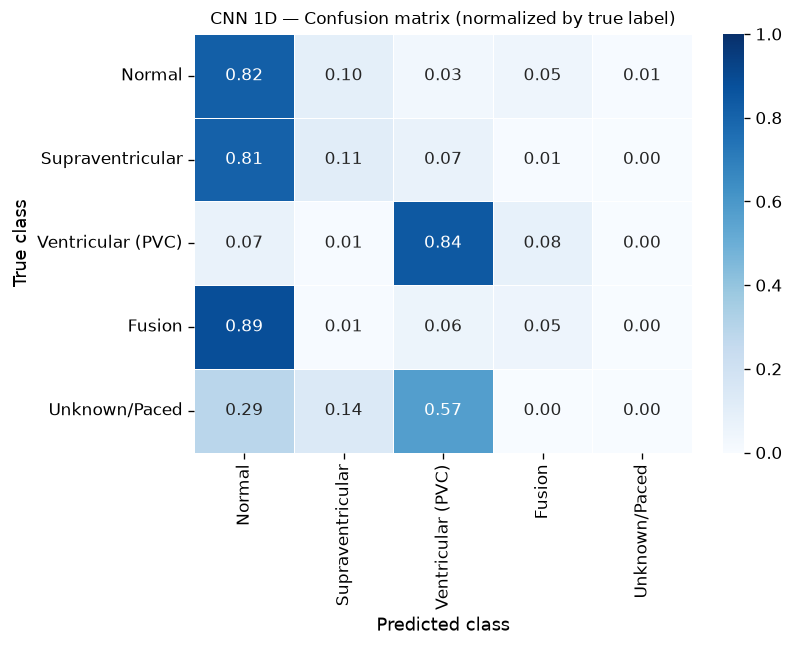

In [44]:
#–– Confusion matrix ––––––––––––––––––––––––––––––––––––––––––––––––––––––––
plot_confusion_matrix(
    y_test, y_pred_lbl,
    labels=CLASSES,
    model_name='CNN 1D',
    save_path=RESULTS_PATH + '05_08_confusion_CNN.png')

### Confusion matrix interpretation

Comparing this matrix directly against the classical model matrices from
Notebook 04 reveals a consistent pattern: the raw-waveform CNN does not
outperform the hand-crafted-feature classical models on any minority
class in this run.

On **class V (PVC)**, the CNN reaches a recall of 0.84, a strong result in
absolute terms but slightly below both Random Forest and SVM (0.90 each).
Class F (Fusion) remains effectively undetectable for every model in the
project, the CNN's recall of 0.05 sits in the same near-zero range as
Random Forest (0.04) and SVM (0.06), and the matrix shows 89% of true F
beats being misclassified as N. This confirms that Fusion ambiguity is
inherent to the signal itself, not an artifact of hand-crafted versus
learned features.

The CNN's clearest weakness is **class S**, where recall collapses to 0.11, the worst result of any model across this project (Random Forest: 0.27, MLP: 0.24, SVM: 0.13). The matrix shows the mechanism directly: 81% of true S beats are misclassified as N. Supraventricular beats are morphologically similar to normal beats and are distinguished clinically mainly by an abnormal R-R interval, timing relative to neighboring beats, rather than by waveform shape alone. A model that only sees a single isolated 200-sample window, with no information about beat-to-beat timing, has no way to access that signal. This lines up with the hand-crafted feature set in Notebook 03, which explicitly included R-R interval features that the classical models could exploit but that the raw-waveform CNN architecture has no mechanism to see. [[2]](#references)

**Class Q (Unknown/Paced)** also drops to a recall of 0.00, with 57% of its
beats misclassified as V and 29% as N. This is expected given the
negligible training signal (8 beats in DS1) rather than a CNN-specific
weakness: Random Forest shows the same 0.00 recall on Q, and only the MLP
achieved any recall on this class in Notebook 04 (0.14), which was already
flagged there as unlikely to reflect genuine generalization given the
sample size.

Taken together, these results suggest that for this specific problem, at this dataset scale, explicit feature engineering still captures diagnostically relevant information, particularly inter-beat timing, that the CNN's convolutional filters, operating on a fixed-length single-beat window, cannot recover on their own.


---
## 10. Per-class recall analysis

Per-class recall — CNN 1D on DS2:

   CNN 1D
N  0.8178
S  0.1116
V  0.8416
F  0.0515
Q  0.0000


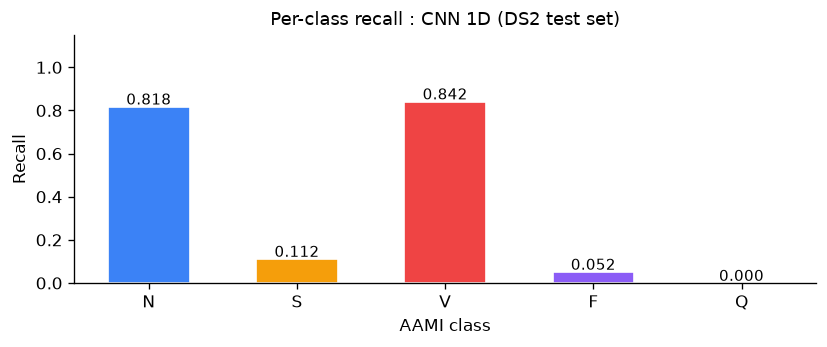

In [41]:
#–– Per-class recall for the CNN ––––––––––––––––––––––––––––––––––––––––––––
cnn_recalls = recall_score(
    y_true_enc, y_pred_enc,
    labels=le.transform(CLASSES),
    average=None,
    zero_division=0
)

recall_df = pd.DataFrame(
    {'CNN 1D': cnn_recalls},
    index=CLASSES
)

print("Per-class recall — CNN 1D on DS2:")
print()
print(recall_df.round(4).to_string())


#–– Visualize per-class recall ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
colors = [CLASS_COLORS[c] for c in CLASSES]
bars   = ax.bar(CLASSES, cnn_recalls, color=colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, cnn_recalls):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_xlabel('AAMI class', fontsize=10)
ax.set_ylabel('Recall', fontsize=10)
ax.set_title('Per-class recall : CNN 1D (DS2 test set)', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_PATH + '05_09_cnn_per_class_recall.png', bbox_inches='tight')
plt.show()

---
## 11. Final comparison: Classical ML vs CNN

We now compare the CNN against the three classical models from
Notebook 04 on the same DS2 test set. This is the central result
of the project.

Enter the F1-macro values from Notebook 04 in the cell below to
produce the comparative figure.

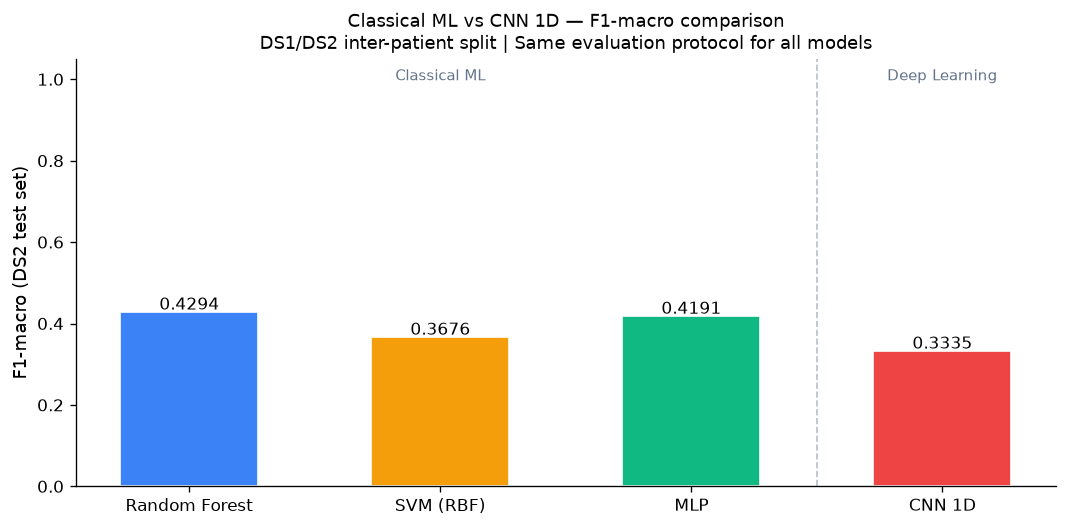

Best classical model : Random Forest (0.4294)
CNN 1D               : 0.3335
Improvement          : -0.0959


In [42]:
#–– Enter F1-macro results from Notebook 04 here ––––––––––––––––––––––––––––
nb04_results = {
    'Random Forest' : 0.4294,   
    'SVM (RBF)'     : 0.3676,   
    'MLP'           : 0.4191,}

all_results = {**nb04_results, 'CNN 1D': cnn_f1}


#–– Comparative bar chart –––––––––––––––––––––––––––––––––––––––––––––––––––
names  = list(all_results.keys())
f1s    = list(all_results.values())
colors = ['#3B82F6', '#F59E0B', '#10B981', '#EF4444']

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(names, f1s, color=colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1-macro (DS2 test set)', fontsize=11)
ax.set_title('Classical ML vs CNN 1D — F1-macro comparison\n'
             'DS1/DS2 inter-patient split | Same evaluation protocol for all models',
             fontsize=11)

# Vertical line separating classical and deep learning
ax.axvline(2.5, color='#94A3B8', linestyle='--', linewidth=1, alpha=0.7)
ax.text(1.0,  ax.get_ylim()[1]*0.95, 'Classical ML', ha='center',
        fontsize=9, color='#64748B')
ax.text(3.0,  ax.get_ylim()[1]*0.95, 'Deep Learning', ha='center',
        fontsize=9, color='#64748B')

plt.tight_layout()
plt.savefig(RESULTS_PATH + '05_10_final_comparison.png', bbox_inches='tight')
plt.show()

best_classical = max(nb04_results, key=nb04_results.get)
improvement    = cnn_f1 - nb04_results[best_classical]
print(f"Best classical model : {best_classical} ({nb04_results[best_classical]:.4f})")
print(f"CNN 1D               : {cnn_f1:.4f}")
print(f"Improvement          : {improvement:+.4f}")

### Interpreting the comparison

This comparison addresses a fundamental question in biomedical signal processing: does the CNN learn better representations than hand-crafted features? For this dataset and this training budget, the answer is no. The CNN reaches an F1-macro of 0.3335 on DS2, below all three classical models, Random Forest (0.4294), MLP (0.4191), and even SVM (0.3676), making it the weakest of the four approaches rather than the strongest.

Several factors converge to explain this result, all of them already
visible earlier in this notebook rather than new findings. 
- First, the training curves in Section 8 showed the CNN overfitting almost
immediately once `WeightedRandomSampler` was used alone: validation loss
reached its minimum by epoch 2 and diverged from training loss for most
of the remaining run, indicating the model has more capacity than the
available minority-class data (414 F beats, 8 Q beats in DS1) can
constrain. 
- Second, the confusion matrix in Section 8 showed the CNN's
sharpest weakness on class S, where recall collapsed to 0.11, which is  worse than any classical model, because supraventricular beats are distinguished clinically by an abnormal R-R interval rather than by waveform shape alone, and a model that only sees a single 200-sample window has no mechanism to access that timing information. The hand-crafted feature set in Notebook 03 explicitly included R-R interval features, which is precisely the kind of information a raw single-beat CNN architecture cannot recover through convolution alone.

This does not mean convolutional architectures are unsuitable for ECG
classification in general; it means that for this specific combination, with severe class imbalance, only 51,008 training beats, single-beat windows with no explicit temporal context, and a relatively shallow 3-layer CNN, explicit feature engineering still captures more clinically relevant signal than the network was able to learn on its own. Published literature confirms this is expected at this scale: CNNs typically outperform classical models when given larger datasets, multi-beat context windows, or architectures deep enough to require less inductive bias, none of which apply here [[3]](#references).

The comparison itself remains scientifically valuable regardless of the outcome. It quantifies, with a controlled and identical evaluation protocol across all four models, exactly where representation learning underperforms feature engineering for this task. The reason is becasue the CNN lacks access to inter-beat timing information, not because convolutional filters have an inherent limitation on waveform morphology. This distinction points directly to a concrete next step for improving the CNN. Feeding it multi-beat windows or explicit R-R interval features alongside the raw waveform would be a logical improvement, rather than concluding that deep learning is the wrong tool for this problem.


---
## 12. Summary and next steps

### What we accomplished in this notebook

1. Loaded the normalized beat waveforms from Notebook 02, the raw
   signal input, without any manual feature engineering.
2. Inspected and verified the `ECGClassifierCNN` architecture from
   `src/models.py`, confirming input/output dimensions with a dummy
   forward pass.
3. Ran a 4-configuration ablation study (Section 5) comparing weighted
   loss and `WeightedRandomSampler`, independently and combined, to
   decide how to address class imbalance in the PyTorch training
   pipeline. The sampler alone (Config 3) was selected as the winner.
4. Trained the CNN with the winning configuration, using the Adam
   optimizer, `ReduceLROnPlateau` scheduler, and early stopping on
   Apple MPS (GPU acceleration).
5. Analyzed training dynamics through loss, accuracy, and learning rate
   curves, identifying an overfitting pattern that begins almost
   immediately once the sampler oversamples minority beats.
6. Evaluated the best checkpoint on DS2, the same inter-patient test set
   used in Notebook 04, used exactly once.
7. Compared CNN performance against all three classical models from
   Notebook 04 on F1-macro and per-class recall, finding that the CNN
   (F1-macro 0.3335) underperforms all three classical models, with
   Random Forest remaining the best overall approach (F1-macro 0.4294).

### Key methodological decisions and their justifications

| Decision | Rationale |
|---|---|
| Raw waveforms as input (not features) | CNN learns representations automatically, testing whether manual features are sufficient |
| 4-configuration ablation study (Section 5) | Empirically decide how to handle class imbalance instead of assuming a strategy |
| WeightedRandomSampler alone, no loss reweighting | Winning configuration from the ablation study; combining both mechanisms caused a double-correction collapse (Config 4) |
| Adam optimizer with weight decay | Fast convergence plus L2 regularization to reduce overfitting on minority classes **[1]** |
| ReduceLROnPlateau (patience=5) | Adapts learning rate to the loss landscape without manual scheduling |
| Early stopping (patience=15) | Prevents wasted computation; restores best weights automatically |
| MPS device (Apple Silicon) | GPU acceleration without CUDA, full reproducibility on Mac hardware |
| DS2 used exactly once | Same protocol as Notebook 04, ensuring a fair comparison between approaches |
| Best checkpoint (not final epoch) | Final epoch may have overfit; the best val loss checkpoint generalizes better |

### Main finding

The CNN trained directly on raw waveforms did not outperform the
hand-crafted-feature classical models from Notebook 04. Its main
weakness, a collapsed recall on class S, is best explained by the
absence of R-R interval information: a single 200-sample window gives
the network no access to beat-to-beat timing, which the classical
models could exploit directly through explicit features. This points to
a concrete direction for future work (multi-beat context windows or
explicit temporal features) rather than a fundamental limitation of
convolutional architectures for this task.

### Figures produced in this notebook

| Figure file | Section | What it shows |
|---|---|---|
| `05_ablation_4configs.png` | 5 | Validation loss and F1-macro curves for the 4 ablation configurations |
| `05_ablation_summary.csv` | 5 | Summary table of Best Val Loss, Best Val F1-Macro, and per-class recall for each ablation configuration |
| `05_07_training_curves.png` | 7 | Loss, accuracy, and learning rate over epochs |
| `05_08_confusion_CNN.png` | 8 | Normalized confusion matrix, CNN 1D |
| `05_09_cnn_per_class_recall.png` | 10 | Per-class recall bar chart, CNN 1D |
| `05_10_final_comparison.png` | 11 | Classical ML vs CNN, F1-macro comparison |


### Project complete

This notebook concludes the five-notebook pipeline:

| Notebook | Topic | Output |
|---|---|---|
| 01 | Data exploration | Dataset characterization, class distribution, morphological analysis |
| 02 | Preprocessing | Filtered, segmented, normalized beat matrix (DS1/DS2 split) |
| 03 | Feature extraction | 21-feature matrix per beat |
| 04 | Classical ML | Trained RF/SVM/MLP with SHAP interpretability |
| 05 | Deep Learning | Trained CNN 1D with final comparative evaluation |


---
<h2 id="references">References</h2>

[1] D. P. Kingma and J. Ba, "Adam: A method for stochastic optimization,"
in *International Conference on Learning Representations (ICLR)*, 2015.
[Online]. Available: https://arxiv.org/abs/1412.6980

[2] P. de Chazal, M. O'Dwyer, and R. B. Reilly, "Automatic
classification of heartbeats using ECG morphology and heartbeat
interval features," *IEEE Transactions on Biomedical Engineering*,
vol. 51, no. 7, pp. 1196–1206, Jul. 2004,
doi: 10.1109/TBME.2004.827359.

[3] P. Rajpurkar et al., "Cardiologist-level arrhythmia detection and
classification in ambulatory electrocardiograms using a deep neural
network," *Nature Medicine*, vol. 25, pp. 65–69, 2019,
doi: 10.1038/s41591-018-0268-3.

